# Pattern Substitution Risk
This notebook demonstrates simple document image analysis tasks related to compression risks.

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

## 1. Pattern Substitution Risk
We load a binary document image, extract connected components, and group similar symbols using a simple area-based rule.

In [2]:
# Load binary document image
img = cv2.imread("document.jpg", cv2.IMREAD_GRAYSCALE)

# Convert to binary (black text on white background)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

# Label connected components (each letter/symbol)
labels = label(binary)
regions = regionprops(labels)

# Extract simple shape descriptor: area + bounding box
features = []
for r in regions:
    features.append({
        "bbox": r.bbox,
        "area": r.area,
        "coords": r.coords
    })

# Very simple similarity function based on area
def similar(r1, r2, area_thresh=0.1):
    return abs(r1["area"] - r2["area"]) / r1["area"] < area_thresh

# Group similar components
groups = []
for r in features:
    placed = False
    for g in groups:
        if similar(r, g[0]):
            g.append(r)
            placed = True
            break
    if not placed:
        groups.append([r])

print("Number of symbol groups:", len(groups))


Number of symbol groups: 16


## 2. Human-Visible vs Machine-Relevant Differences
We compress an image at different JPEG qualities and compare PSNR, SSIM, and edge detection results.

JPEG Quality 90: PSNR=40.02, SSIM=0.985


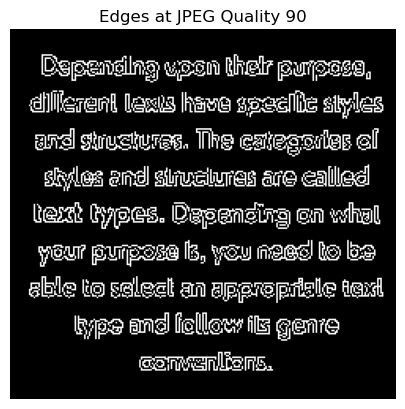

JPEG Quality 50: PSNR=30.57, SSIM=0.939


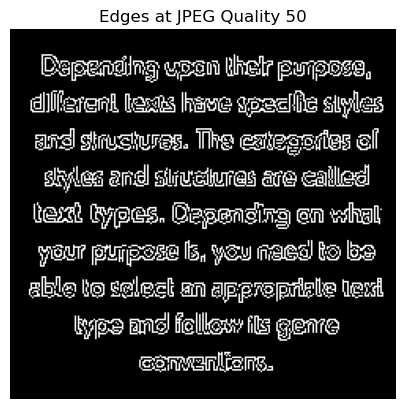

JPEG Quality 20: PSNR=26.08, SSIM=0.900


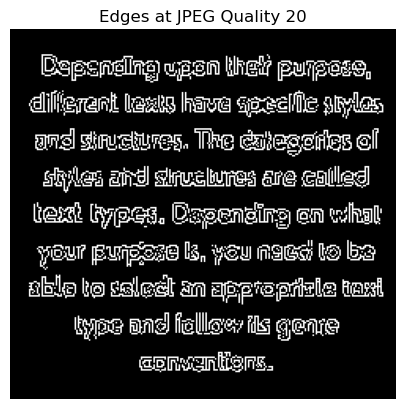

In [3]:
img = cv2.imread("text.png", cv2.IMREAD_GRAYSCALE)
qualities = [90, 50, 20]

for q in qualities:
    cv2.imwrite(f"compressed_{q}.jpg", img, [cv2.IMWRITE_JPEG_QUALITY, q])
    comp = cv2.imread(f"compressed_{q}.jpg", cv2.IMREAD_GRAYSCALE)
    
    psnr = peak_signal_noise_ratio(img, comp)
    ssim = structural_similarity(img, comp)
    
    edges = cv2.Canny(comp, 100, 200)
    
    print(f"JPEG Quality {q}: PSNR={psnr:.2f}, SSIM={ssim:.3f}")
    
    plt.imshow(edges, cmap='gray')
    plt.title(f"Edges at JPEG Quality {q}")
    plt.axis("off")
    plt.show()


## 3. Silent Data Corruption Detection
We compare a lossless and lossy scan to highlight suspicious regions.

In [1]:
lossless = cv2.imread("scan_lossless.jpeg", cv2.IMREAD_GRAYSCALE)
lossy = cv2.imread("scan_lossy_com.png", cv2.IMREAD_GRAYSCALE)

# Safety checks
if lossless is None or lossy is None:
    raise FileNotFoundError("❌ scan_lossless.png or scan_lossy.png not found")

print("Before resize:")
print("Lossless:", lossless.shape)
print("Lossy:", lossy.shape)

# Resize lossy image to match lossless
lossy = cv2.resize(lossy, (lossless.shape[1], lossless.shape[0]))

print("After resize:")
print("Lossy:", lossy.shape)

# Absolute difference
diff = cv2.absdiff(lossless, lossy)

# Threshold to highlight differences
_, diff_bin = cv2.threshold(diff, 20, 255, cv2.THRESH_BINARY)

# Remove noise using morphology
kernel = np.ones((3,3), np.uint8)
diff_bin = cv2.morphologyEx(diff_bin, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(6,6))
plt.imshow(diff_bin, cmap='gray')
plt.title("Potential Corruption Regions")
plt.axis("off")
plt.show()

NameError: name 'cv2' is not defined

In [5]:
print("Lossless shape:", lossless.shape)
print("Lossy shape:", lossy.shape)

Lossless shape: (956, 768)
Lossy shape: (956, 768)


## 4. Compression Breaking a Downstream Task
A simple rule-based digit classifier tested on compressed images.

In [6]:

def simple_digit_classifier(region):
    h, w = region.shape
    return "1" if h > 2*w else "0"

correct = 0
total = 0

for q in [90, 50, 20]:
    comp = cv2.imread(f"digits_{q}.jpg", cv2.IMREAD_GRAYSCALE)
    _, bin_img = cv2.threshold(comp, 127, 255, cv2.THRESH_BINARY_INV)
    labels = label(bin_img)
    
    for r in regionprops(labels):
        digit = simple_digit_classifier(bin_img[r.slice])
        if digit == "1":  # assume ground truth is "1"
            correct += 1
        total += 1

print("Accuracy:", correct / total)


Accuracy: 0.0


## 5. Designing a Safe Compression Rule
We decide compression type based on entropy and edge density.

In [7]:

def entropy(image):
    hist = np.histogram(image.flatten(), bins=256)[0]
    prob = hist / hist.sum()
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def edge_density(image):
    edges = cv2.Canny(image, 100, 200)
    return np.sum(edges > 0) / edges.size

def compression_decision(image):
    e = entropy(image)
    d = edge_density(image)
    if d > 0.15:
        return "Use lossless compression"
    elif e < 4:
        return "Lossy compression safe"
    else:
        return "Use high-quality lossy"

decision = compression_decision(img)
print(decision)

Lossy compression safe
